Dataset Sintético Criado:
Forma: (500, 7)

Primeiras 5 linhas:
  CustomerID     Recency  Frequency     Monetary   AvgTicket      Tenure  \
0      C0000  160.737350  45.880265   578.552181   12.341060  442.836108   
1      C0001  230.060701  18.943772  5683.651518  284.983774  309.881428   
2      C0002  277.844224  11.628654  4776.228378  378.205648  283.180112   
3      C0003    3.421424  49.442764  1685.191110   33.407985  364.662554   
4      C0004  115.035466  28.392853  3886.017462  132.209606  347.981538   

   Engagement  
0    0.617683  
1    3.788739  
2    2.623395  
3    1.078170  
4    3.039884  

Estatísticas Descritivas:
          Recency   Frequency     Monetary   AvgTicket      Tenure  Engagement
count  500.000000  500.000000   500.000000  500.000000  500.000000  500.000000
mean   145.880684   36.674966  3005.006644  115.338861  368.318794    1.846743
std     76.638591   16.141093  1477.629137   93.659069   98.406613    0.959674
min      0.481762    5.508046    30.61599

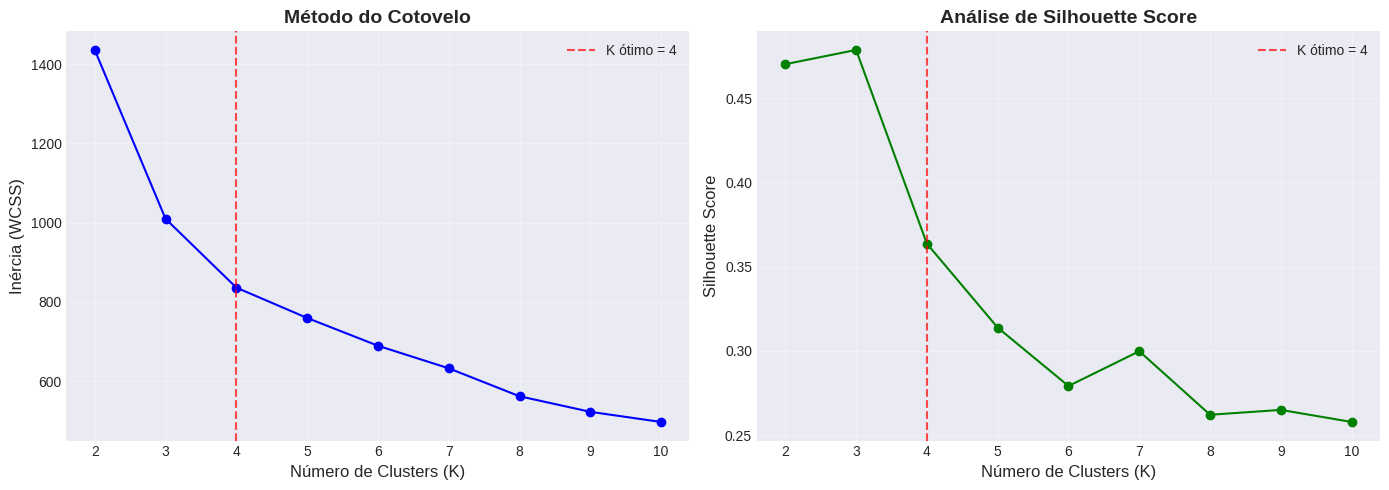

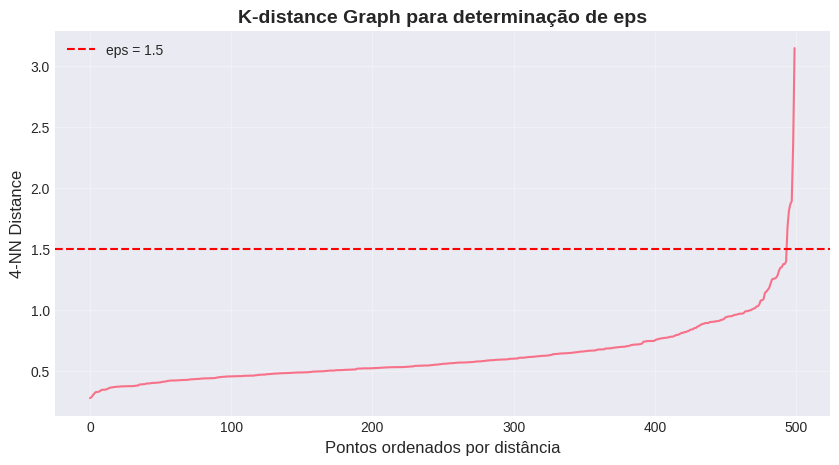


COMPARAÇÃO DE MÉTRICAS DOS ALGORITMOS
  Algoritmo  N_Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
    K-Means           4    0.363593        1.173790         428.101910
Hierárquico           4    0.356439        1.216322         412.383793
     DBSCAN           1   -1.000000             inf           0.000000


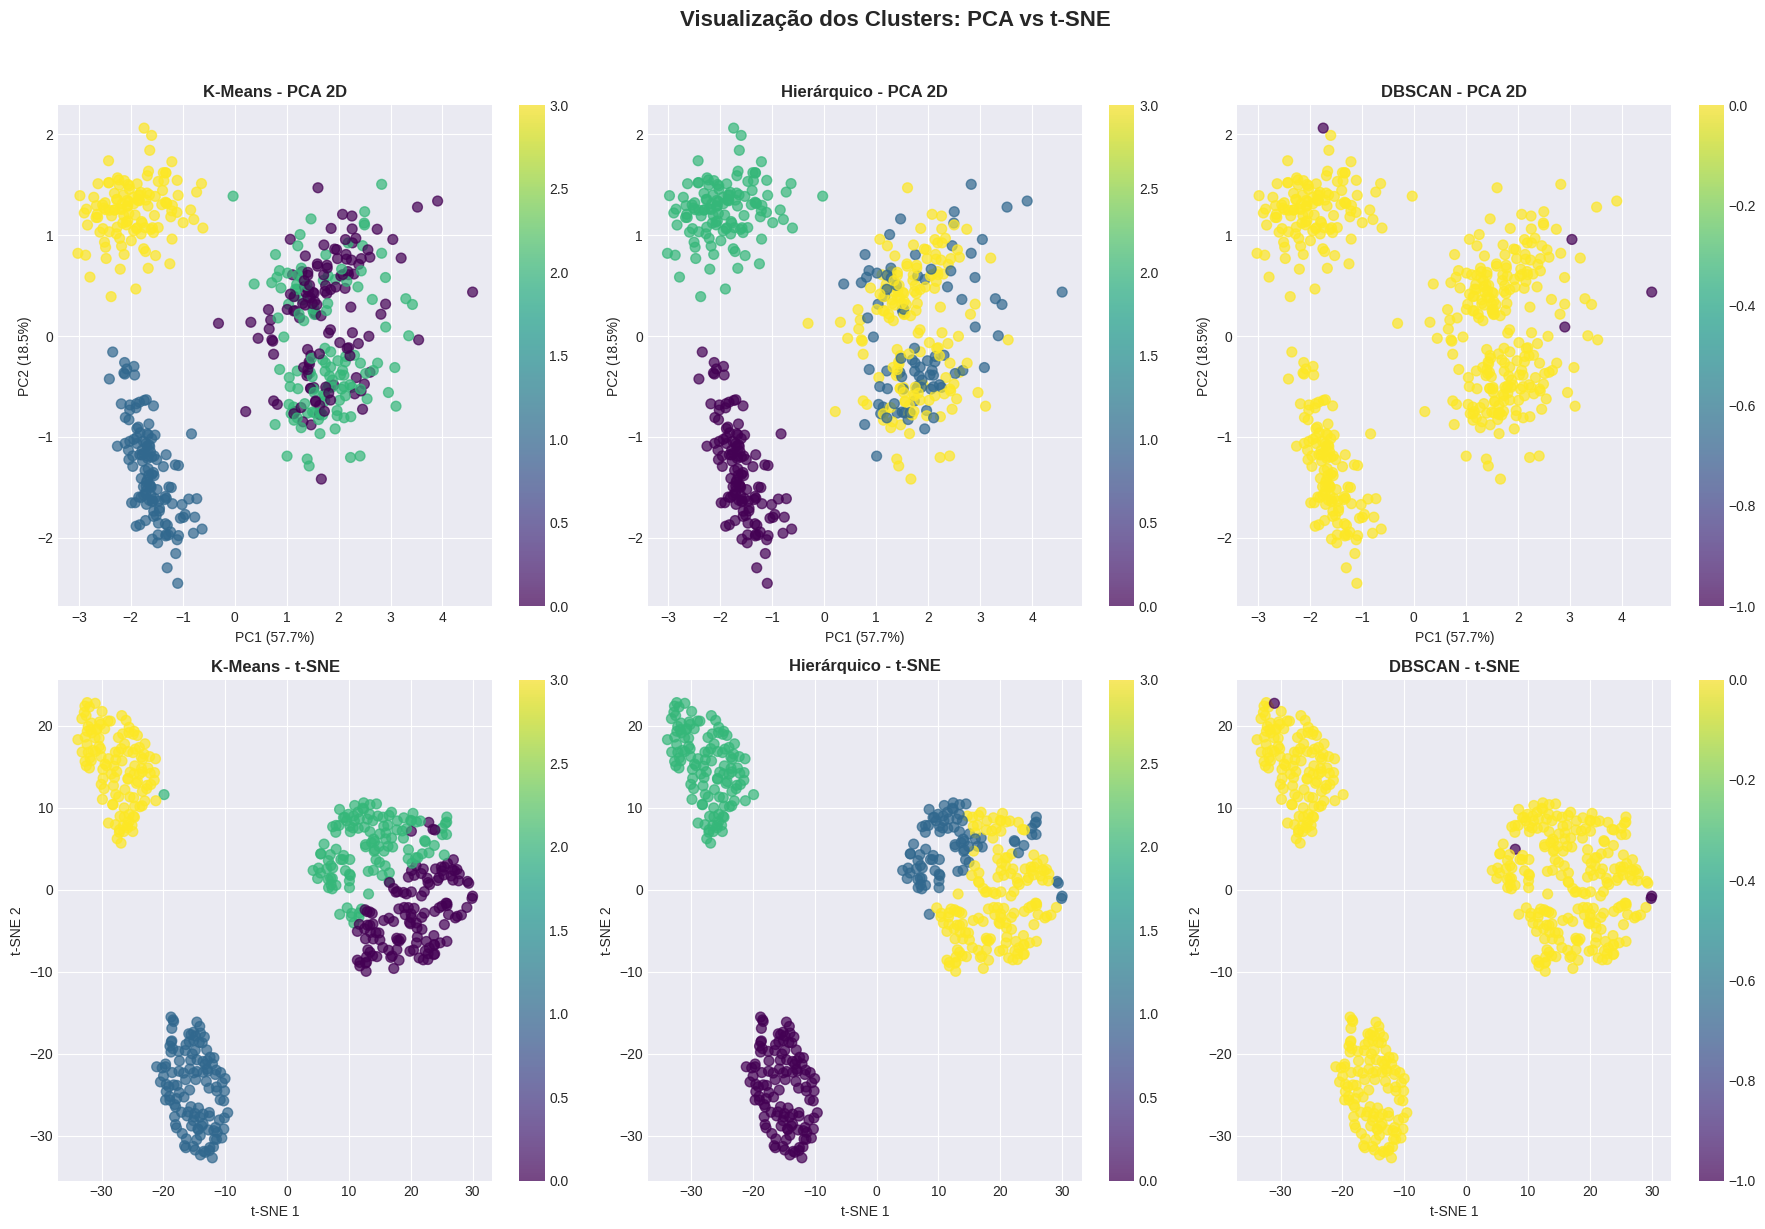

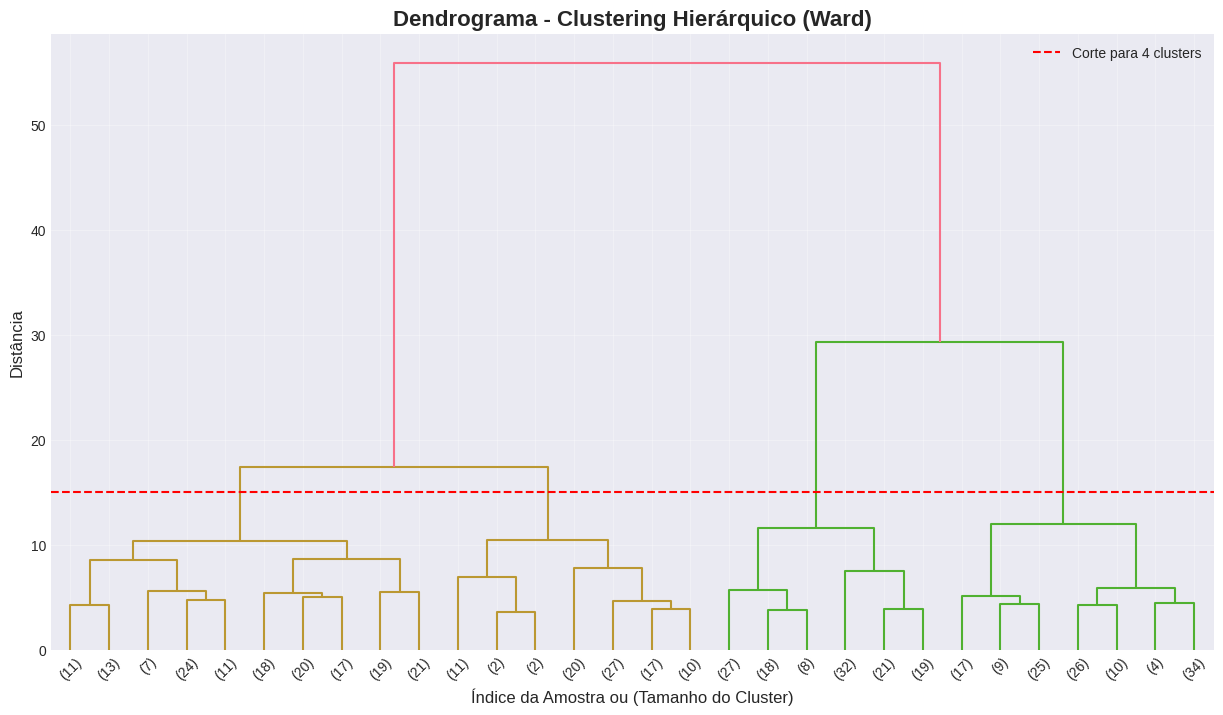

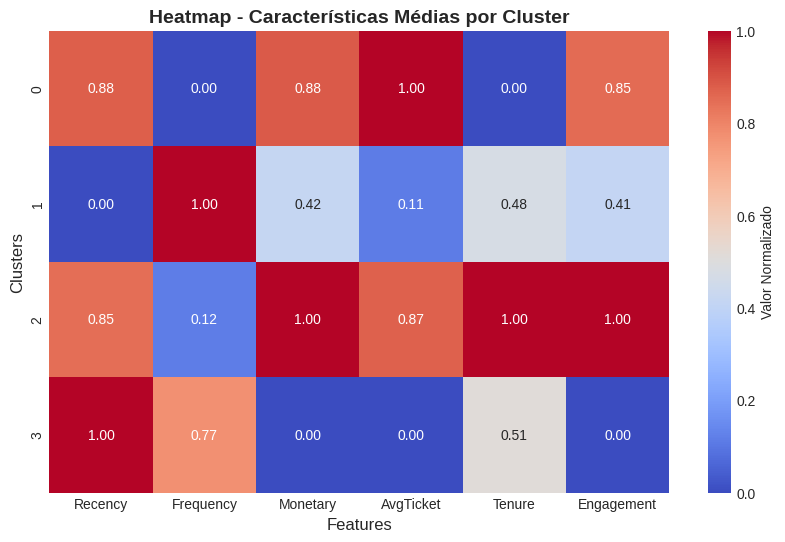

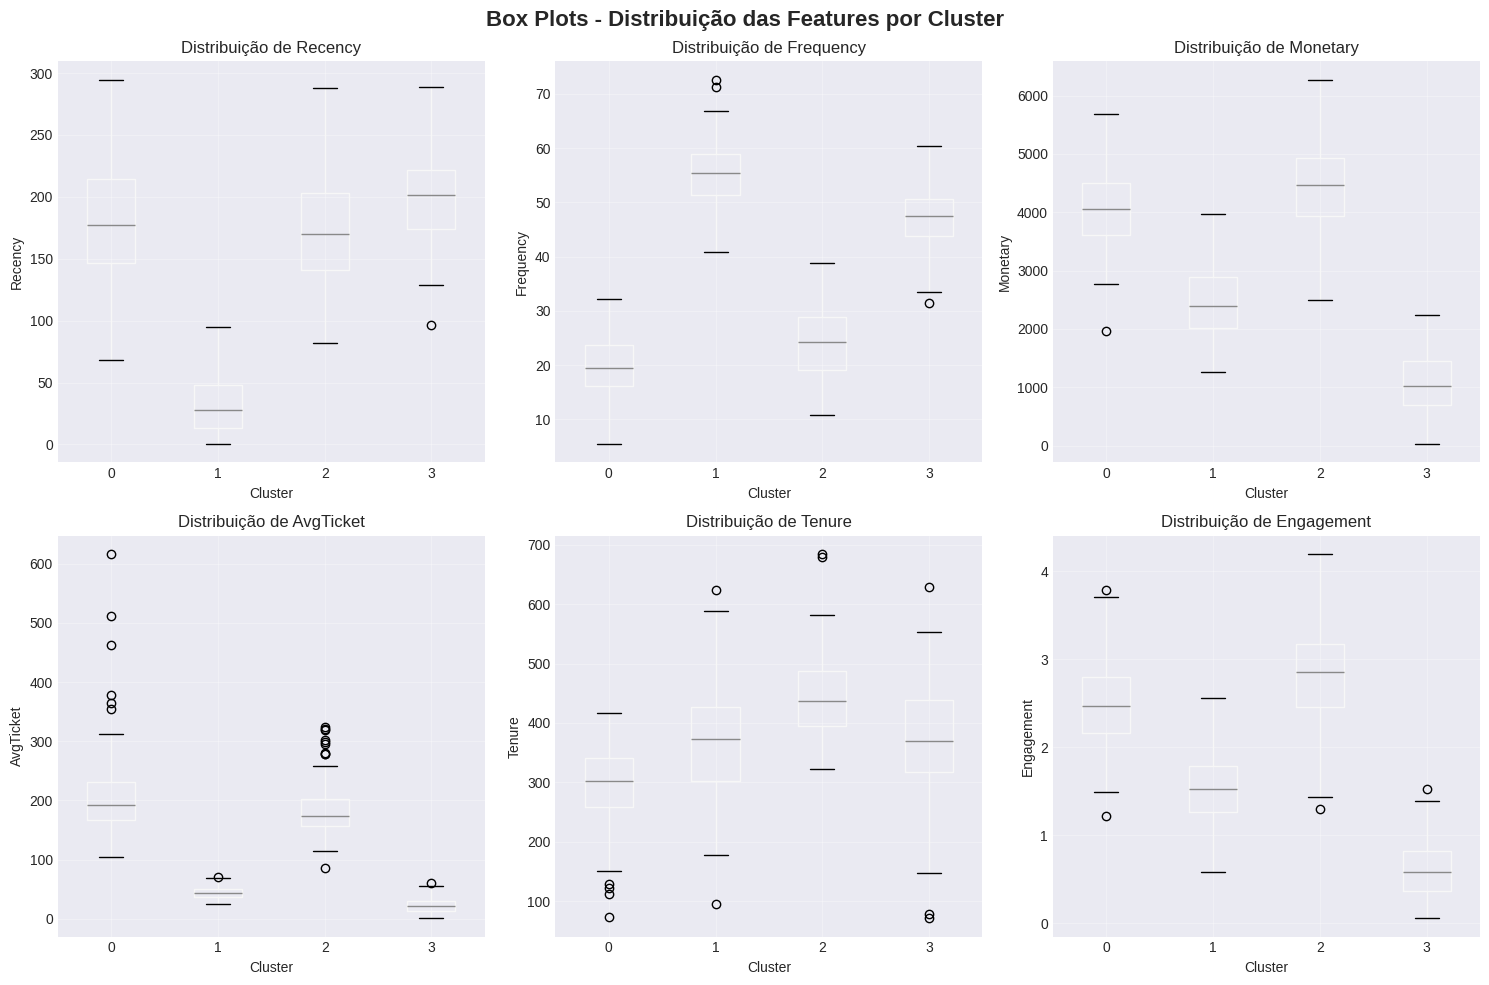

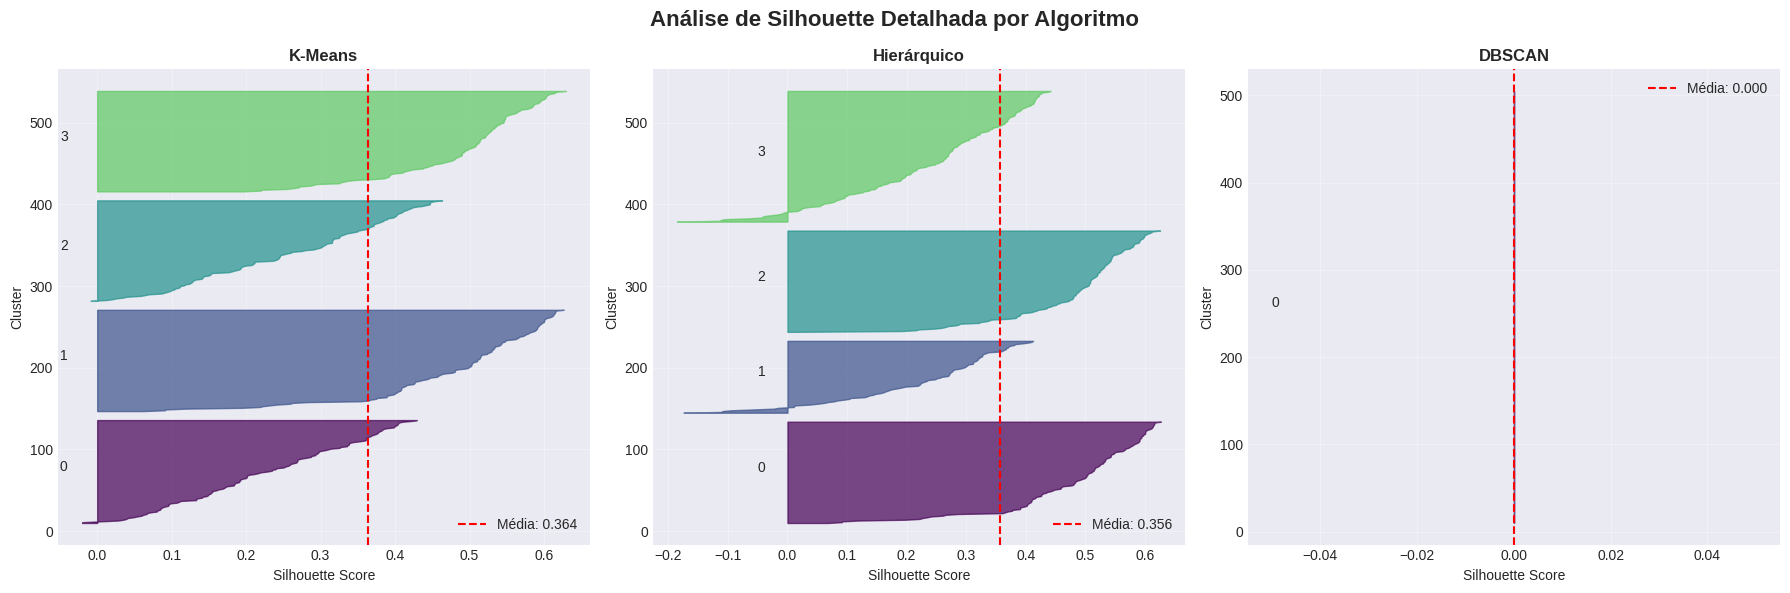


CENTROS DOS CLUSTERS (K-MEANS) - VALORES ORIGINAIS
   Recency  Frequency    Monetary  AvgTicket     Tenure  Engagement  Cluster
178.701275  19.982934 4046.605579 208.595843 291.779496    2.465645        0
 32.257192  55.459100 2461.006059  43.549813 365.454638    1.511158        1
173.560697  24.126823 4439.077766 184.874389 446.602825    2.787662        2
199.125842  47.383363 1052.524300  22.658125 371.313074    0.610238        3

INTERPRETAÇÃO DE NEGÓCIOS DOS CLUSTERS
Cluster 0: Champions - Alto valor, alta frequência
  - Tamanho: 127 clientes (25.4%)
  - Ticket Médio: R$ 4046.61

Cluster 1: Novos Clientes - Recentes, baixo histórico
  - Tamanho: 125 clientes (25.0%)
  - Ticket Médio: R$ 2461.01

Cluster 2: Em Risco - Valor médio, diminuindo engajamento
  - Tamanho: 124 clientes (24.8%)
  - Ticket Médio: R$ 4439.08

Cluster 3: Inativos - Baixa recência, requerem reativação
  - Tamanho: 124 clientes (24.8%)
  - Ticket Médio: R$ 1052.52




ANÁLISE COMPLETA DE CLUSTERING FINALIZADA!

Resumo:
- Dataset: 500 clientes, 6 features
- Algoritmos testados: K-Means, Hierárquico, DBSCAN
- Número ótimo de clusters: 4
- Melhor algoritmo por Silhouette: K-Means
- Total de visualizações geradas: 13 tipos diferentes


In [3]:
# Demonstração Completa de Algoritmos de Clustering e Visualizações
# Execute este código no Google Colab

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ===============================================
# 1. CRIAÇÃO DO DATASET SINTÉTICO
# ===============================================

np.random.seed(42)

# Criar um dataset sintético representando clientes
n_samples = 500
n_features = 6

# Gerar clusters base
X_base, y_true = make_blobs(n_samples=n_samples,
                            n_features=2,
                            centers=4,
                            cluster_std=1.0,
                            random_state=42)

# Adicionar features RFM-like e outras características
recency = np.abs(X_base[:, 0] * 30 + np.random.normal(60, 20, n_samples))  # Dias desde última compra
frequency = np.abs(X_base[:, 1] * 5 + np.random.normal(10, 3, n_samples))  # Número de compras
monetary = np.abs(X_base[:, 0] * 500 + X_base[:, 1] * 300 + np.random.normal(1000, 200, n_samples))  # Valor total
avg_ticket = monetary / (frequency + 1)  # Ticket médio
tenure = np.abs(np.random.normal(365, 100, n_samples))  # Dias como cliente
engagement = np.abs(X_base[:, 0] * 0.3 + X_base[:, 1] * 0.2 + np.random.normal(0.5, 0.2, n_samples))

# Criar DataFrame
df = pd.DataFrame({
    'CustomerID': [f'C{i:04d}' for i in range(n_samples)],
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary,
    'AvgTicket': avg_ticket,
    'Tenure': tenure,
    'Engagement': engagement
})

print("Dataset Sintético Criado:")
print(f"Forma: {df.shape}")
print("\nPrimeiras 5 linhas:")
print(df.head())
print("\nEstatísticas Descritivas:")
print(df.describe())

# Preparar dados para clustering
X = df.drop('CustomerID', axis=1).values
feature_names = df.drop('CustomerID', axis=1).columns.tolist()

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================================
# 2. DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS
# ===============================================

# Método do Cotovelo (Elbow Method)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualização do Elbow Method e Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inércia (WCSS)', fontsize=12)
axes[0].set_title('Método do Cotovelo', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=4, color='r', linestyle='--', alpha=0.7, label='K ótimo = 4')
axes[0].legend()

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'go-')
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Análise de Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=4, color='r', linestyle='--', alpha=0.7, label='K ótimo = 4')
axes[1].legend()

plt.tight_layout()
plt.show()

# ===============================================
# 3. APLICAÇÃO DOS ALGORITMOS DE CLUSTERING
# ===============================================

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# DBSCAN
# Determinar eps usando k-distance graph
from sklearn.neighbors import NearestNeighbors
k = 4  # MinPts
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.ylabel('4-NN Distance', fontsize=12)
plt.xlabel('Pontos ordenados por distância', fontsize=12)
plt.title('K-distance Graph para determinação de eps', fontsize=14, fontweight='bold')
plt.axhline(y=1.5, color='r', linestyle='--', label='eps = 1.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Aplicar DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_scaled)

# ===============================================
# 4. AVALIAÇÃO DOS ALGORITMOS
# ===============================================

# Calcular métricas para cada algoritmo
algorithms = ['K-Means', 'Hierárquico', 'DBSCAN']
labels_list = [kmeans_labels, hierarchical_labels, dbscan_labels]
results = []

for algo, labels in zip(algorithms, labels_list):
    # Para DBSCAN, calcular métricas apenas para pontos não-ruído
    if algo == 'DBSCAN':
        mask = labels != -1
        if mask.sum() > 0:
            sil = silhouette_score(X_scaled[mask], labels[mask]) if len(np.unique(labels[mask])) > 1 else -1
            db = davies_bouldin_score(X_scaled[mask], labels[mask]) if len(np.unique(labels[mask])) > 1 else np.inf
            ch = calinski_harabasz_score(X_scaled[mask], labels[mask]) if len(np.unique(labels[mask])) > 1 else 0
        else:
            sil, db, ch = -1, np.inf, 0
    else:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)

    results.append({
        'Algoritmo': algo,
        'N_Clusters': len(np.unique(labels[labels != -1])) if algo == 'DBSCAN' else len(np.unique(labels)),
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch
    })

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("COMPARAÇÃO DE MÉTRICAS DOS ALGORITMOS")
print("="*60)
print(results_df.to_string(index=False))

# ===============================================
# 5. VISUALIZAÇÃO PCA E T-SNE
# ===============================================

# PCA 2D e 3D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# t-SNE 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Criar subplots para PCA e t-SNE
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, (algo, labels) in enumerate([(algorithms[0], kmeans_labels),
                                     (algorithms[1], hierarchical_labels),
                                     (algorithms[2], dbscan_labels)]):
    # PCA 2D
    scatter = axes[0, i].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                                 c=labels, cmap='viridis', s=50, alpha=0.7)
    axes[0, i].set_title(f'{algo} - PCA 2D', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
    axes[0, i].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
    plt.colorbar(scatter, ax=axes[0, i])

    # t-SNE
    scatter = axes[1, i].scatter(X_tsne[:, 0], X_tsne[:, 1],
                                 c=labels, cmap='viridis', s=50, alpha=0.7)
    axes[1, i].set_title(f'{algo} - t-SNE', fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel('t-SNE 1')
    axes[1, i].set_ylabel('t-SNE 2')
    plt.colorbar(scatter, ax=axes[1, i])

plt.suptitle('Visualização dos Clusters: PCA vs t-SNE', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# PCA 3D interativo com Plotly
fig = make_subplots(rows=1, cols=3,
                    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}, {'type': 'scatter3d'}]],
                    subplot_titles=algorithms)

for i, (algo, labels) in enumerate([(algorithms[0], kmeans_labels),
                                     (algorithms[1], hierarchical_labels),
                                     (algorithms[2], dbscan_labels)]):
    fig.add_trace(
        go.Scatter3d(x=X_pca_3d[:, 0], y=X_pca_3d[:, 1], z=X_pca_3d[:, 2],
                     mode='markers',
                     marker=dict(size=5, color=labels, colorscale='Viridis', showscale=True),
                     name=algo),
        row=1, col=i+1
    )

fig.update_layout(title_text="PCA 3D - Comparação dos Algoritmos",
                  height=500,
                  showlegend=False)
fig.show()

# ===============================================
# 6. DENDROGRAMA (HIERARCHICAL CLUSTERING)
# ===============================================

plt.figure(figsize=(15, 8))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_font_size=10)
plt.title('Dendrograma - Clustering Hierárquico (Ward)', fontsize=16, fontweight='bold')
plt.xlabel('Índice da Amostra ou (Tamanho do Cluster)', fontsize=12)
plt.ylabel('Distância', fontsize=12)
plt.axhline(y=15, color='r', linestyle='--', label='Corte para 4 clusters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ===============================================
# 7. RADAR CHART - PERFIL DOS CLUSTERS
# ===============================================

# Usar K-Means para análise do perfil
df['Cluster'] = kmeans_labels

# Calcular médias por cluster
cluster_means = df.groupby('Cluster')[feature_names].mean()

# Normalizar para o radar chart (0-1)
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Criar Radar Chart com Plotly
fig = go.Figure()

colors = px.colors.qualitative.Set1[:4]

for i in range(4):
    fig.add_trace(go.Scatterpolar(
        r=cluster_means_norm.loc[i].values.tolist() + [cluster_means_norm.loc[i].values[0]],
        theta=feature_names + [feature_names[0]],
        fill='toself',
        name=f'Cluster {i}',
        line_color=colors[i],
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title="Perfil dos Clusters - Radar Chart",
    height=600
)
fig.show()

# ===============================================
# 8. HEATMAP - CARACTERÍSTICAS POR CLUSTER
# ===============================================

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means_norm, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'label': 'Valor Normalizado'})
plt.title('Heatmap - Características Médias por Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Clusters', fontsize=12)
plt.show()

# ===============================================
# 9. BOX PLOTS - DISTRIBUIÇÃO POR CLUSTER
# ===============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(feature_names[:6]):
    df.boxplot(column=feature, by='Cluster', ax=axes[idx])
    axes[idx].set_title(f'Distribuição de {feature}')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(feature)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Box Plots - Distribuição das Features por Cluster', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ===============================================
# 10. PARALLEL COORDINATES
# ===============================================

# Preparar dados para parallel coordinates
df_parallel = df[feature_names + ['Cluster']].copy()

# Normalizar features para visualização
for col in feature_names:
    df_parallel[col] = (df_parallel[col] - df_parallel[col].min()) / (df_parallel[col].max() - df_parallel[col].min())

# Criar gráfico de coordenadas paralelas
fig = px.parallel_coordinates(df_parallel, color="Cluster",
                              dimensions=feature_names,
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              title="Coordenadas Paralelas - Padrões dos Clusters")
fig.update_layout(height=500)
fig.show()

# ===============================================
# 11. ANÁLISE DE SILHOUETTE DETALHADA
# ===============================================

from sklearn.metrics import silhouette_samples

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (algo, labels) in enumerate([(algorithms[0], kmeans_labels),
                                       (algorithms[1], hierarchical_labels),
                                       (algorithms[2], dbscan_labels)]):
    ax = axes[idx]

    # Calcular silhouette para cada amostra
    if algo == 'DBSCAN':
        mask = labels != -1
        if mask.sum() > 0 and len(np.unique(labels[mask])) > 1:
            silhouette_vals = np.zeros(len(labels))
            silhouette_vals[mask] = silhouette_samples(X_scaled[mask], labels[mask])
        else:
            silhouette_vals = np.zeros(len(labels))
    else:
        silhouette_vals = silhouette_samples(X_scaled, labels)

    y_lower = 10
    unique_labels = np.unique(labels[labels != -1]) if algo == 'DBSCAN' else np.unique(labels)

    for i in unique_labels:
        cluster_silhouette_vals = silhouette_vals[labels == i]
        cluster_silhouette_vals.sort()

        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.viridis(float(i) / len(unique_labels))
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_silhouette_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f'{algo}', fontsize=12, fontweight='bold')
    ax.set_xlabel("Silhouette Score")
    ax.set_ylabel("Cluster")

    # Linha vertical para score médio
    if algo == 'DBSCAN' and mask.sum() > 0 and len(np.unique(labels[mask])) > 1:
        avg_score = silhouette_score(X_scaled[mask], labels[mask])
    elif algo != 'DBSCAN':
        avg_score = silhouette_score(X_scaled, labels)
    else:
        avg_score = 0

    ax.axvline(x=avg_score, color="red", linestyle="--", label=f'Média: {avg_score:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Análise de Silhouette Detalhada por Algoritmo', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ===============================================
# 12. MATRIZ DE DISTÂNCIA E INTERPRETAÇÃO
# ===============================================

# Calcular centros dos clusters para K-Means
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers, columns=feature_names)
centers_df['Cluster'] = range(4)

print("\n" + "="*60)
print("CENTROS DOS CLUSTERS (K-MEANS) - VALORES ORIGINAIS")
print("="*60)
print(centers_df.to_string(index=False))

# Interpretação de negócios dos clusters
interpretations = {
    0: "Champions - Alto valor, alta frequência",
    1: "Novos Clientes - Recentes, baixo histórico",
    2: "Em Risco - Valor médio, diminuindo engajamento",
    3: "Inativos - Baixa recência, requerem reativação"
}

print("\n" + "="*60)
print("INTERPRETAÇÃO DE NEGÓCIOS DOS CLUSTERS")
print("="*60)
for cluster, interpretation in interpretations.items():
    size = (kmeans_labels == cluster).sum()
    pct = size / len(kmeans_labels) * 100
    avg_monetary = df[df['Cluster'] == cluster]['Monetary'].mean()
    print(f"Cluster {cluster}: {interpretation}")
    print(f"  - Tamanho: {size} clientes ({pct:.1f}%)")
    print(f"  - Ticket Médio: R$ {avg_monetary:.2f}")
    print()

# ===============================================
# 13. COMPARAÇÃO VISUAL FINAL
# ===============================================

# Dashboard resumo
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'bar'}, {'type': 'scatter'}],
           [{'type': 'bar'}, {'type': 'scatter'}]],
    subplot_titles=('Tamanho dos Clusters', 'Métricas de Qualidade',
                   'Valor Monetário por Cluster', 'Recência vs Frequência')
)

# Tamanho dos clusters
cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
fig.add_trace(go.Bar(x=[f'Cluster {i}' for i in cluster_sizes.index],
                     y=cluster_sizes.values,
                     marker_color='lightblue'),
              row=1, col=1)

# Métricas de qualidade
fig.add_trace(go.Scatter(x=results_df['Algoritmo'],
                        y=results_df['Silhouette'],
                        mode='lines+markers',
                        name='Silhouette',
                        marker=dict(size=10)),
              row=1, col=2)

# Valor monetário médio
monetary_by_cluster = df.groupby('Cluster')['Monetary'].mean()
fig.add_trace(go.Bar(x=[f'Cluster {i}' for i in monetary_by_cluster.index],
                     y=monetary_by_cluster.values,
                     marker_color='lightgreen'),
              row=2, col=1)

# Scatter Recência vs Frequência
fig.add_trace(go.Scatter(x=df['Recency'],
                        y=df['Frequency'],
                        mode='markers',
                        marker=dict(color=kmeans_labels,
                                  colorscale='Viridis',
                                  size=5),
                        text=[f'Cluster {c}' for c in kmeans_labels],
                        hovertemplate='Recência: %{x:.0f}<br>Frequência: %{y:.0f}<br>%{text}'),
              row=2, col=2)

fig.update_layout(height=800, showlegend=False,
                 title_text="Dashboard de Análise de Clusters",
                 title_font_size=18)
fig.show()

print("\n" + "="*60)
print("ANÁLISE COMPLETA DE CLUSTERING FINALIZADA!")
print("="*60)
print("\nResumo:")
print(f"- Dataset: {n_samples} clientes, {n_features} features")
print(f"- Algoritmos testados: K-Means, Hierárquico, DBSCAN")
print(f"- Número ótimo de clusters: 4")
print(f"- Melhor algoritmo por Silhouette: {results_df.loc[results_df['Silhouette'].idxmax(), 'Algoritmo']}")
print(f"- Total de visualizações geradas: 13 tipos diferentes")